<a href="https://colab.research.google.com/github/sarabdar/pytorch/blob/main/Stochastic_Gradient_Decent_in_Pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import Dataset, DataLoader
from mpl_toolkits import mplot3d

In [2]:
torch.manual_seed(1)

# For Plotting

In [3]:
# The class for plot the diagram

class plot_error_surfaces(object):

    # Constructor
    def __init__(self, w_range, b_range, X, Y, n_samples = 30, go = True):
        W = np.linspace(-w_range, w_range, n_samples)
        B = np.linspace(-b_range, b_range, n_samples)
        w, b = np.meshgrid(W, B)
        Z = np.zeros((30, 30))
        count1 = 0
        self.y = Y.numpy()
        self.x = X.numpy()
        for w1, b1 in zip(w, b):
            count2 = 0
            for w2, b2 in zip(w1, b1):
                Z[count1, count2] = np.mean((self.y - w2 * self.x + b2) ** 2)
                count2 += 1
            count1 += 1
        self.Z = Z
        self.w = w
        self.b = b
        self.W = []
        self.B = []
        self.LOSS = []
        self.n = 0
        if go == True:
            plt.figure()
            plt.figure(figsize = (7.5, 5))
            plt.axes(projection = '3d').plot_surface(self.w, self.b, self.Z, rstride = 1, cstride = 1,cmap = 'viridis', edgecolor = 'none')
            plt.title('Loss Surface')
            plt.xlabel('w')
            plt.ylabel('b')
            plt.show()
            plt.figure()
            plt.title('Loss Surface Contour')
            plt.xlabel('w')
            plt.ylabel('b')
            plt.contour(self.w, self.b, self.Z)
            plt.show()

    # Setter
    def set_para_loss(self, W, B, loss):
        self.n = self.n + 1
        self.W.append(W)
        self.B.append(B)
        self.LOSS.append(loss)

    # Plot diagram
    def final_plot(self):
        ax = plt.axes(projection = '3d')
        ax.plot_wireframe(self.w, self.b, self.Z)
        ax.scatter(self.W, self.B, self.LOSS, c = 'r', marker = 'x', s = 200, alpha = 1)
        plt.figure()
        plt.contour(self.w, self.b, self.Z)
        plt.scatter(self.W, self.B, c = 'r', marker = 'x')
        plt.xlabel('w')
        plt.ylabel('b')
        plt.show()

    # Plot diagram
    def plot_ps(self):
        plt.subplot(121)
        plt.ylim
        plt.plot(self.x, self.y, 'ro', label = "training points")
        plt.plot(self.x, self.W[-1] * self.x + self.B[-1], label = "estimated line")
        plt.xlabel('x')
        plt.ylabel('y')
        plt.ylim((-10, 15))
        plt.title('Data Space Iteration: ' + str(self.n))
        plt.subplot(122)
        plt.contour(self.w, self.b, self.Z)
        plt.scatter(self.W, self.B, c = 'r', marker = 'x')
        plt.title('Loss Surface Contour Iteration' + str(self.n))
        plt.xlabel('w')
        plt.ylabel('b')
        plt.show()

In [4]:
class Data(Dataset):

    # Constructor
    def __init__(self):
        self.x = torch.arange(-3, 3, 0.1).view(-1, 1)
        self.y = 1 * self.x - 1
        self.len = self.x.shape[0]

    # Getter
    def __getitem__(self,index):
        return self.x[index], self.y[index]

    # Return the length
    def __len__(self):
        return self.len

In [5]:
dataset = Data()
print("The length of dataset: ", len(dataset))

The length of dataset:  60


In [6]:
x, y = dataset[0:3]
print("The first 3 x: ", x)
print("The first 3 y: ", y)

The first 3 x:  tensor([[-3.0000],
        [-2.9000],
        [-2.8000]])
The first 3 y:  tensor([[-4.0000],
        [-3.9000],
        [-3.8000]])


In [7]:
get_surface = plot_error_surfaces(15, 13, x, y, 30, go = False)

In [8]:
# Create DataLoader

trainloader = DataLoader(dataset = dataset, batch_size = 1)

In [11]:
def forward(x):
  yhat = x * w + b
  return yhat

def criterion(yhat, y):
  return torch.mean((yhat - y) ** 2)

In [14]:
# The function for training the model
lr = 0.1
w = torch.tensor(-15.0,requires_grad=True)
b = torch.tensor(-10.0,requires_grad=True)
LOSS_Loader = []

def train_model_DataLoader(epochs):

    # Loop
    for epoch in range(epochs):

        # SGD is an approximation of out true total loss/cost, in this line of code we calculate our true loss/cost and store it
        Yhat = forward(x)

        # store the loss
        LOSS_Loader.append(criterion(Yhat, y).tolist())

        for x, y in trainloader:

            # make a prediction
            yhat = forward(x)

            # calculate the loss
            loss = criterion(yhat, y)

            # Section for plotting
            get_surface.set_para_loss(w.data.tolist(), b.data.tolist(), loss.tolist())

            # Backward pass: compute gradient of the loss with respect to all the learnable parameters
            loss.backward()

            # Updata parameters slope
            w.data = w.data - lr * w.grad.data
            b.data = b.data - lr* b.grad.data

            # Clear gradients
            w.grad.data.zero_()
            b.grad.data.zero_()

        #plot surface and data space after each epoch
        get_surface.plot_ps()

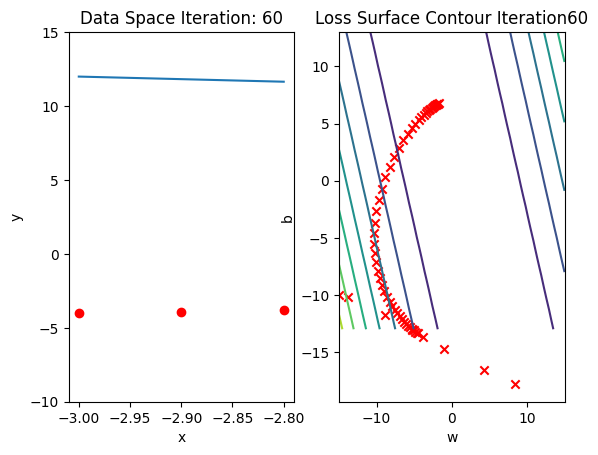

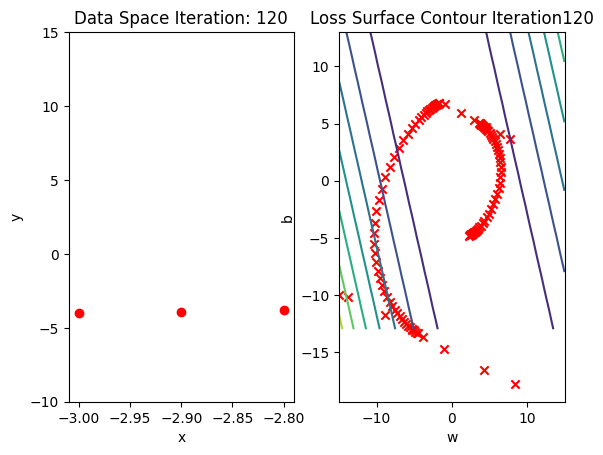

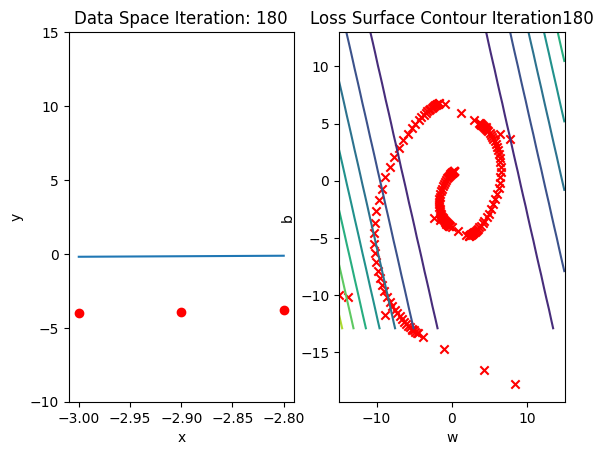

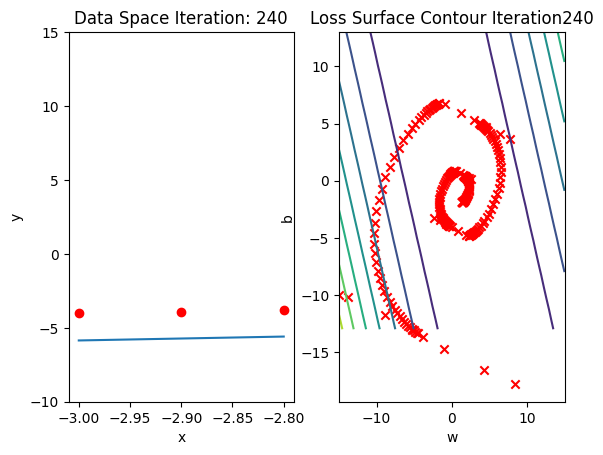

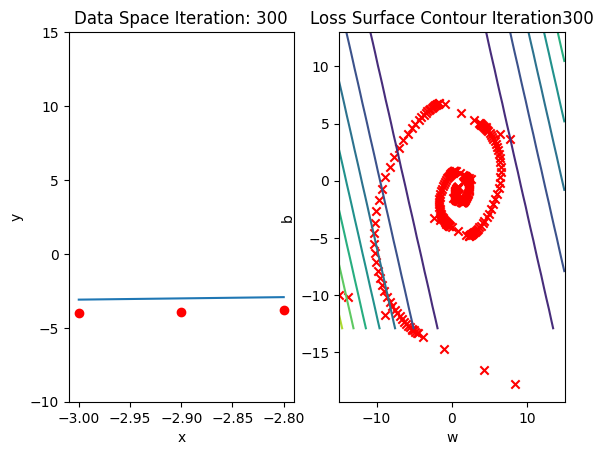

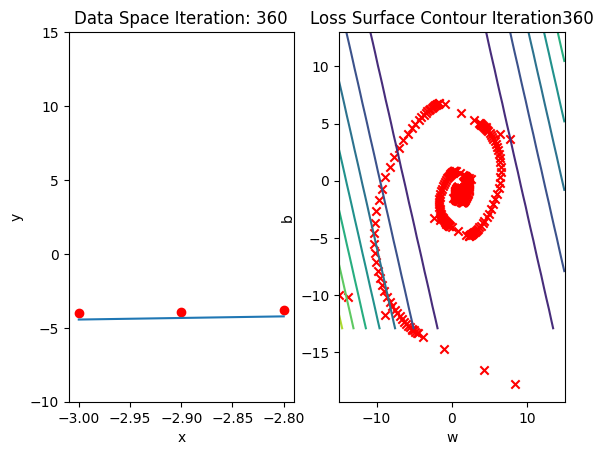

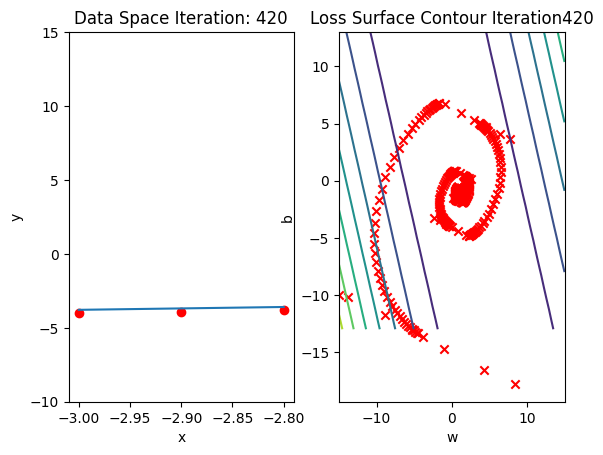

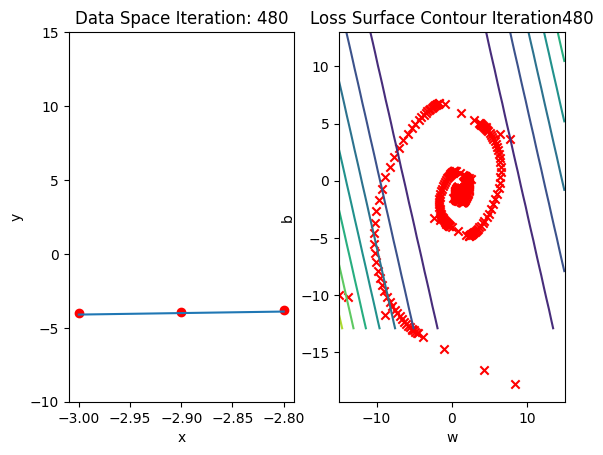

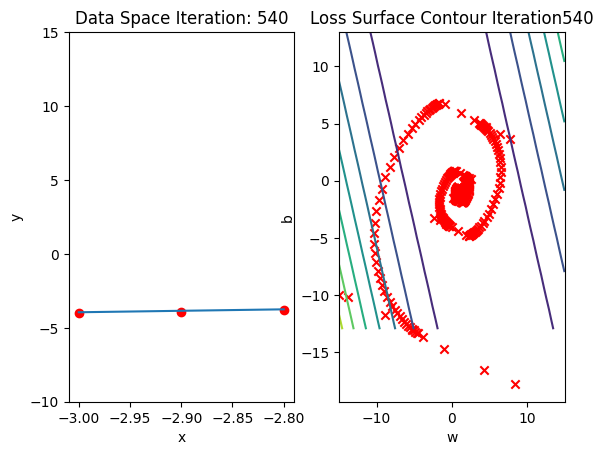

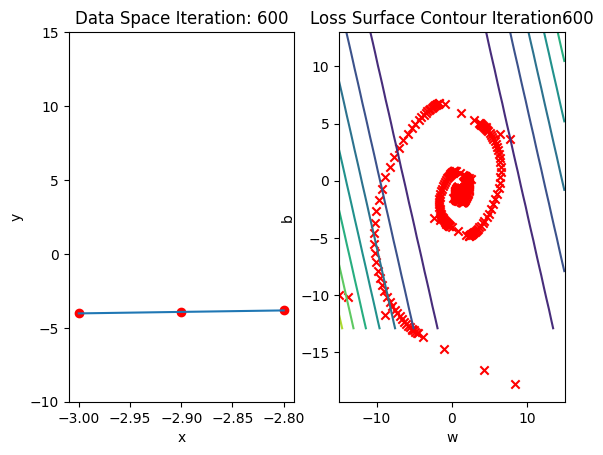

In [16]:
def train_model_DataLoader(epochs):
    # Loop
    for epoch in range(epochs):

        # SGD is an approximation of our true total loss/cost, in this line of code we calculate our true loss/cost and store it
        # Use the full dataset's x and y for overall loss calculation
        Yhat_full = forward(dataset.x)
        # store the loss
        LOSS_Loader.append(criterion(Yhat_full, dataset.y).tolist())

        for batch_x, batch_y in trainloader:

            # make a prediction
            yhat = forward(batch_x)

            # calculate the loss
            loss = criterion(yhat, batch_y)

            # Section for plotting
            get_surface.set_para_loss(w.data.tolist(), b.data.tolist(), loss.tolist())

            # Backward pass: compute gradient of the loss with respect to all the learnable parameters
            loss.backward()

            # Update parameters slope
            w.data = w.data - lr * w.grad.data
            b.data = b.data - lr* b.grad.data

            # Clear gradients
            w.grad.data.zero_()
            b.grad.data.zero_()

        #plot surface and data space after each epoch
        get_surface.plot_ps()

train_model_DataLoader(10)

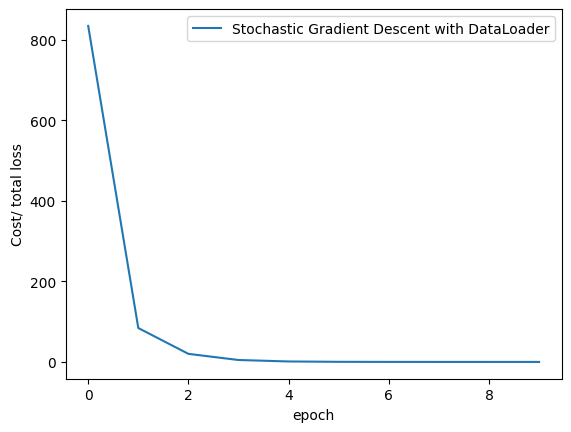

In [17]:
plt.plot(LOSS_Loader,label="Stochastic Gradient Descent with DataLoader")
plt.xlabel('epoch')
plt.ylabel('Cost/ total loss')
plt.legend()
plt.show()